In [64]:
import sys
sys.path.insert(0, "src")  # src/ contains core library modules

from instance_generator import InstanceGenerator

import pandas as pd
import seaborn as sns
from pprint import pprint
import pickle
import osmnx as ox
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp
import json
from farmers_intermediaries import Instance
from names_generator import generate_name

sns.set_theme(context='paper', style='dark')
INDO_CRS = "EPSG:23867"
RES = 250

farmers_df = pd.read_csv('data/farmers.csv')
ints_df = pd.read_csv('data/ints.csv')
mills_df  = pd.read_csv('data/mills.csv')

with open("../FactoredPlatformSolver/data/graph_0-14960_00.pickle", 'rb') as pickle_file:
    G = pickle.load(pickle_file)

G_proj = ox.project_graph(G, to_crs=INDO_CRS)

/var/folders/7_/y4vpj6ln7b90djzq_hscbgyr0000gn/T/ipykernel_60056/2369490603.py:28: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  G = pickle.load(pickle_file)


In [65]:
df = farmers_df

In [66]:
ig = InstanceGenerator(farmers_df, ints_df, "../FactoredPlatformSolver/data/graph_0-14960_00.pickle")

/Users/nachatjatusripitak/Desktop/Paper Revision/SyntheticInstanceGenerator/src/instance_generator.py:88: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  G = pickle.load(f)


In [71]:
import hashlib
import json
import numpy as np
import random

def get_hash(instance):
    """Returns a hash of the generated coordinates and quantities."""
    # We serialize the farmers and intermediaries to a string and hash it
    data = json.dumps({
        'f': instance['farmers'], 
        'i': instance['intermediaries']
    }, sort_keys=True, default=str)
    return hashlib.md5(data.encode()).hexdigest()

def verify_seeding(test_seed, test_m, generator):
    # --- Run 1 ---
    random.seed(test_seed)
    np.random.seed(test_seed)
    generator.gen_ints(test_m)
    inst1 = generator.gen_instance("test1", write=False, plot=False)
    hash1 = get_hash(inst1)
    
    # --- Run 2 ---
    random.seed(test_seed)
    np.random.seed(test_seed)
    generator.gen_ints(test_m)
    inst2 = generator.gen_instance("test2", write=False, plot=False)
    hash2 = get_hash(inst2)
    
    # --- Results ---
    print(f"Seed: {test_seed} | M: {test_m}")
    print(f"Hash 1: {hash1}")
    print(f"Hash 2: {hash2}")
    
    if hash1 == hash2:
        print("✅ SUCCESS: Data is perfectly reproducible.")
    else:
        print("❌ FAILURE: Instances diverged.")
        # Check specific counts to narrow down the leak
        print(f"Farmers: {len(inst1['farmers'])} vs {len(inst2['farmers'])}")
        print(f"Ints: {len(inst1['intermediaries'])} vs {len(inst2['intermediaries'])}")

# Run the check
verify_seeding(100, 10, ig)

Seed: 100 | M: 10
Hash 1: cb87c885d3aee9c9da8603a3bc32c428
Hash 2: cb87c885d3aee9c9da8603a3bc32c428
✅ SUCCESS: Data is perfectly reproducible.


In [50]:
ig.gen_ints(1)

ig.ints

{'Relaxed Varahamihira': {'xy': array([879523.04099234, -54858.74072481]),
  'll': (-0.49544010121946735, 102.40877840890495),
  'type': 'Syafrial'}}

In [51]:
ig.ints['Relaxed Varahamihira']['type'] = 'Purnomo'

In [59]:
instance = ig.gen_instance('test', write=False, plot=False)

len(instance['farmers'])

1

89

In [25]:
Platform = Instance.from_dict(ig.gen_instance('China', write=False, plot=False))

Platform

PlatformInstance(id=China)

In [26]:
def reset_fixed_costs():
    return {intermediary.id: Platform.dist_to_mill[intermediary.id]*4+np.random.normal(0, 100000) for intermediary in Platform.intermediaries}

In [6]:
from road_graphs import RoadGraph
import pickle
import pandas as pd
from pricing import Optimizer

In [7]:
epsilon = {int.id: np.random.uniform(0, 6.0) for int in Platform.intermediaries}

with open("data/graph_0-14960_00.pickle", 'rb') as pickle_file:
    G = pickle.load(pickle_file)
Platform.set_graph(RoadGraph(G))

farmer_quantities = {farmer.id: farmer.quantity for farmer in Platform.farmers}
het_costs = reset_fixed_costs()
parameters = {
    "epsilon":epsilon, 
    "solver": "gurobi", 
    "het_costs": het_costs,
}
farmer_dirt_to_mill = {farmer.id: farmer.dirt_to_mill for farmer in Platform.farmers}
farmer_paved_to_mill = {farmer.id: farmer.paved_to_mill for farmer in Platform.farmers}

opt = Optimizer(Platform, parameters)

summary_vanilla = opt.solve("heuristic_optimized", options={
    "structured_farmer_prices": False,
    "domination": False,})

/var/folders/7_/y4vpj6ln7b90djzq_hscbgyr0000gn/T/ipykernel_25628/994841260.py:4: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  G = pickle.load(pickle_file)


Calculated dominance relations: [('Infallible Hermann', 'Suspicious Kalam'), ('Wonderful Vaughan', 'Suspicious Kalam'), ('Laughing Torvalds', 'Infallible Hermann'), ('Laughing Torvalds', 'Bold Einstein'), ('Laughing Torvalds', 'Suspicious Kalam'), ('Interesting Bouman', 'Infallible Hermann'), ('Interesting Bouman', 'Bold Einstein'), ('Interesting Bouman', 'Suspicious Kalam'), ('Interesting Bouman', 'Goofy Colden'), ('Interesting Bouman', 'Great Khayyam'), ('Bold Einstein', 'Suspicious Kalam'), ('Serene Swartz', 'Suspicious Kalam'), ('Wonderful Lichterman', 'Infallible Hermann'), ('Wonderful Lichterman', 'Bold Einstein'), ('Wonderful Lichterman', 'Suspicious Kalam'), ('Wonderful Lichterman', 'Goofy Colden'), ('Wonderful Lichterman', 'Great Khayyam'), ('Goofy Colden', 'Infallible Hermann'), ('Goofy Colden', 'Suspicious Kalam'), ('Great Khayyam', 'Infallible Hermann'), ('Great Khayyam', 'Suspicious Kalam'), ('Great Khayyam', 'Goofy Colden')]
Solving VRP
Set parameter Username
Set paramete

### Bootstrap dataset

In [19]:
MIN_CAPACITY, MAX_CAPACITY = 2, 9

In [20]:
def instance_to_dfs(instance):
    # Process Farmers
    df_farmers = pd.DataFrame(instance['farmers'])
    df_farmers['farmer_lat'] = df_farmers['location'].apply(lambda x: x[0])
    df_farmers['farmer_lon'] = df_farmers['location'].apply(lambda x: x[1])
    df_farmers['farmer_x'], df_farmers['farmer_y'] = ig.ll_to_xy.transform(
        df_farmers.farmer_lon.values, df_farmers.farmer_lat.values)
    
    df_farmers.drop('location', axis=1)

    # Add a column to identify which intermediary they belong to
    df_farmers['int_id'] = df_farmers['id'].apply(lambda x: x.split('_')[0])

    # Process Intermediaries
    df_ints = pd.DataFrame(instance['intermediaries'])
    df_ints['int_lat'] = df_ints['location'].apply(lambda x: x[0])
    df_ints['int_lon'] = df_ints['location'].apply(lambda x: x[1])
    df_ints['int_x'], df_ints['int_y'] = ig.ll_to_xy.transform(
        df_ints.int_lon.values, df_ints.int_lat.values)
    
    df_ints.drop('location', axis=1)

    df_combined = df_farmers.merge(df_ints, how='left', left_on='int_id', right_on='id')

    df_combined['distance'] = np.sqrt((df_combined.farmer_x - df_combined.int_x) ** 2 + (df_combined.farmer_y - df_combined.int_y) ** 2)
    
    return df_combined

def enforce_capacity(df, max_cap=MAX_CAPACITY, min_cap=MIN_CAPACITY):
    # Calculate the current daily sum for every farmer's group
    # Using transform keeps the index aligned with the original dataframe
    group_totals = df.groupby(['int_id', 'date'])['quantity'].transform('sum')
    
    # 1. Handle the Ceiling: total_q > MAX_CAPACITY
    # We use (max_cap - 0.01) to mirror your generator's safety margin
    over_mask = group_totals > max_cap
    if over_mask.any():
        sf_over = (max_cap - 1e-2) / group_totals
        df.loc[over_mask, 'quantity'] *= sf_over[over_mask]
    
    # Recalculate totals after ceiling adjustment for the floor logic
    group_totals = df.groupby(['int_id', 'date'])['quantity'].transform('sum')
    
    # 2. Handle the Floor: total_q < MIN_CAPACITY
    under_mask = group_totals < min_cap
    if under_mask.any():
        sf_under = min_cap / group_totals
        df.loc[under_mask, 'quantity'] *= sf_under[under_mask]
        
    return df

In [23]:
def compute_perturbations(group, period=14):
    dates = group['date'].values.astype('datetime64[D]')
    t = (dates - dates[0]).astype(int)

    # estimate cycle indices
    n = np.round(t / period).astype(int)

    # compute phase: t = phi + 14n -> phi = t - 14n
    phi = int(np.round(np.median(t - period * n)))

    # compute perturbation
    epsilon = t - (phi + period * n)
    out = group.copy()
    out['epsilon'] = epsilon
    return out


df_3 = farmers_df.copy()
df_3['date'] = pd.to_datetime(df_3['date'])
df_3.sort_values(['int_id', 'farmer_x', 'farmer_y', 'date'], inplace=True)

pert_hist = (
    df_3
    .groupby(['int_id', 'farmer_x', 'farmer_y'], group_keys=True)
    .apply(compute_perturbations)
    .reset_index() # Converts group keys back into columns
)

eps = pert_hist['epsilon']

N_CYCLES = 5
HARVEST_CYCLE = 10 # Days in one full rotation
all_cycles = []

for k in range(HARVEST_CYCLE * N_CYCLES):
    instance = ig.gen_instance('test', write=False, plot=False)
    df = instance_to_dfs(instance)
    df['date'] = k
    all_cycles.append(df)

# Final formatting
df = pd.concat(all_cycles)
df = enforce_capacity(df)

df.sort_values(by=['int_id', 'date'], inplace=True)
df.rename(columns={'id': 'farmer_id'}, inplace=True)

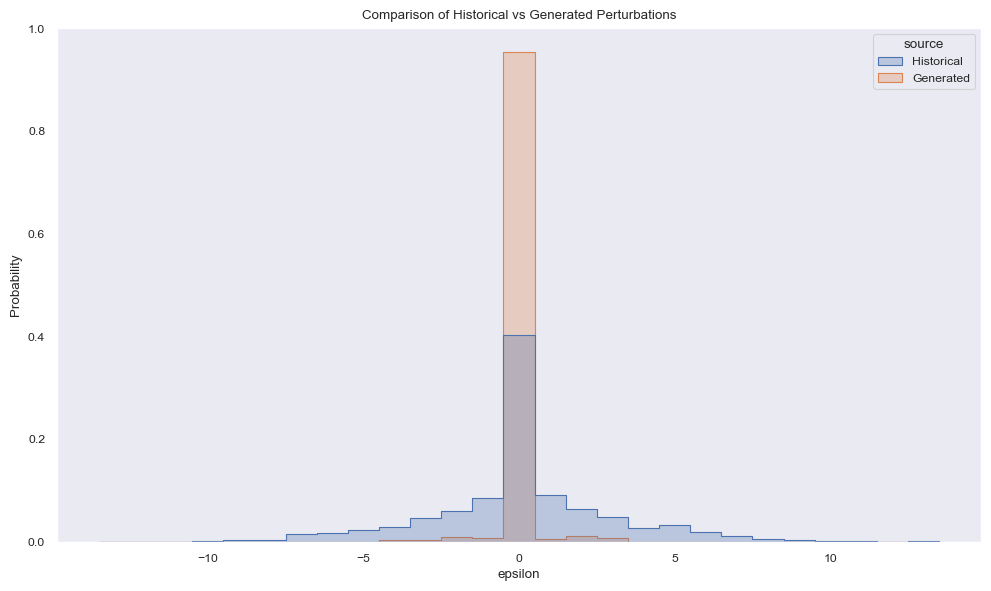

In [24]:
df_3 = farmers_df.copy()
df_3['date'] = pd.to_datetime(df_3['date'])
df_3.sort_values(['int_id', 'farmer_x', 'farmer_y', 'date'], inplace=True)

# 1. Compute perturbations and flatten the resulting index immediately
pert_hist = (
    df_3
    .groupby(['int_id', 'farmer_x', 'farmer_y'], group_keys=True)
    .apply(compute_perturbations)
    .reset_index() # Converts group keys back into columns
)
pert_hist['source'] = 'Historical'

pert_gen = (
    df
    .groupby(['int_id', 'farmer_x', 'farmer_y'], group_keys=True)
    .apply(compute_perturbations)
    .reset_index()
)
pert_gen['source'] = 'Generated'

pert_hist_df = pert_hist.reset_index()
pert_gen_df = pert_gen.reset_index()

# 2. Add source labels
pert_hist_df['source'] = 'Historical'
pert_gen_df['source'] = 'Generated'

# 3. Combine
df_combined = pd.concat([pert_hist_df, pert_gen_df], ignore_index=True)

# 4. Plotting
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_combined, 
    x='epsilon', 
    hue='source', 
    discrete=True,      # Keeps bins aligned to integers
    alpha=0.3,         # Sets transparency for the fill
    element="step",    # 'step' or 'poly' helps distinguish overlapping areas
    common_norm=False,  # Normalizes each source independently if volumes differ
    stat='probability'
)

plt.title("Comparison of Historical vs Generated Perturbations")
plt.tight_layout()
plt.show()

### How many farmers are in each intermediary's network?

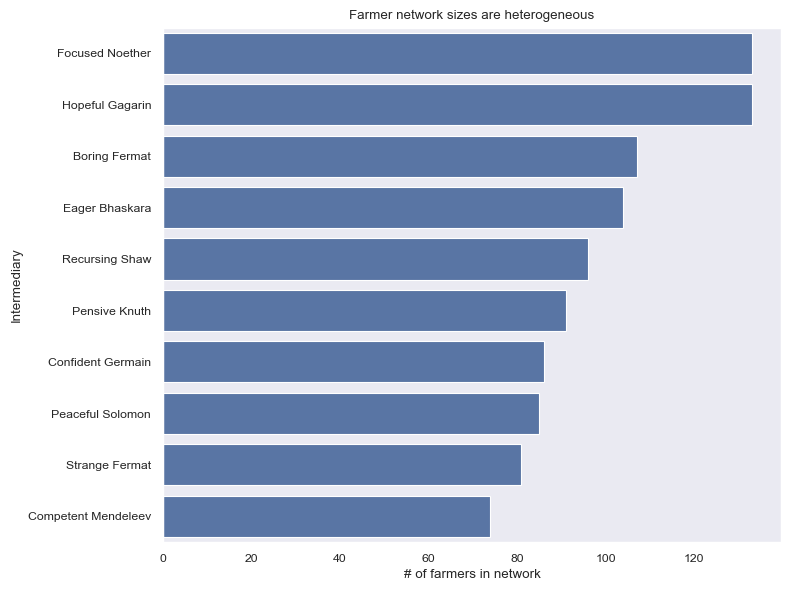

In [25]:
df_1 = df.copy()
res_1 = df_1.drop_duplicates(['int_id', 'farmer_x', 'farmer_y']).groupby('int_id').size()
res_1.sort_values(inplace=True, ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=res_1.values, y=res_1.index)

plt.ylabel('Intermediary')
plt.xlabel('# of farmers in network')
plt.title('Farmer network sizes are heterogeneous')

plt.tight_layout()
plt.show()

### Verify: n_farmers matches (by type)

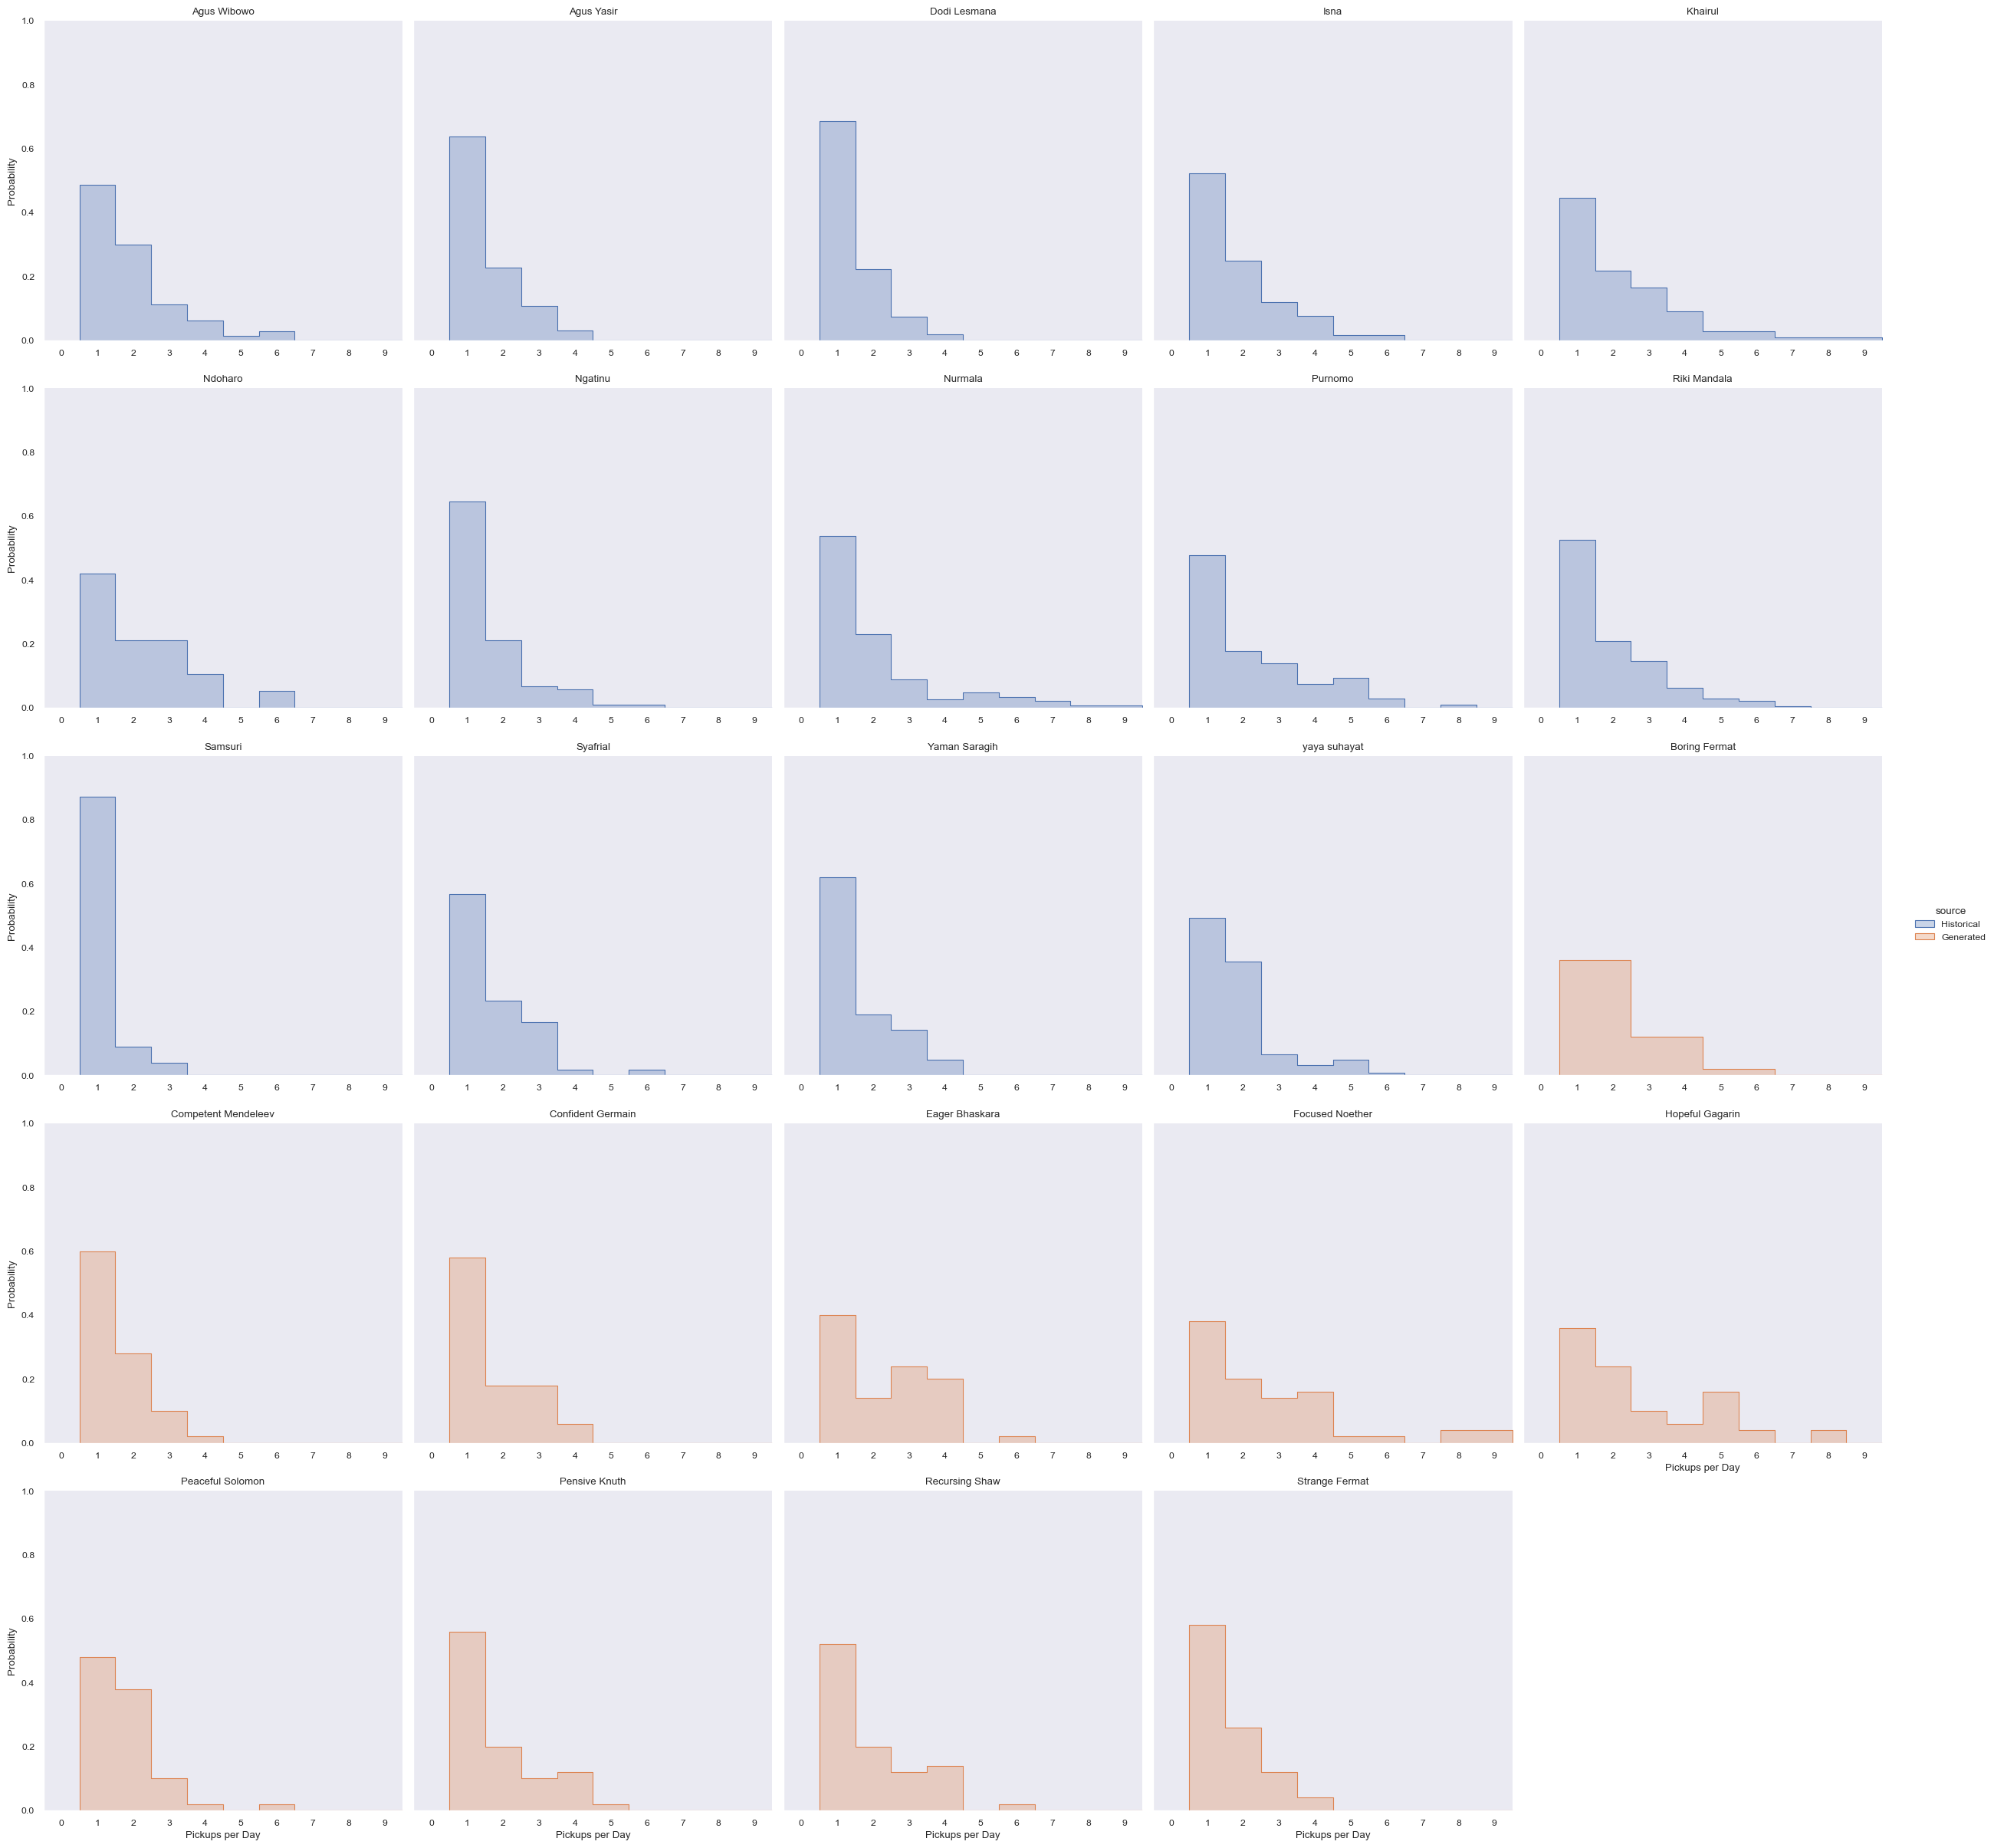

In [26]:
pickups_hist = farmers_df.groupby(['int_id', 'date']).size().reset_index(name='count')
pickups_hist['source'] = 'Historical'

pickups_gen = df.groupby(['int_id', 'date']).size().reset_index(name='count')
pickups_gen['source'] = 'Generated'

df_combined = pd.concat([pickups_hist, pickups_gen], ignore_index=True)

max_count = df_combined['count'].max()
bins = np.arange(-0.5, max_count + 1.5, 1)

g = sns.displot(
    data=df_combined,
    x='count',
    hue='source',          # This creates the overlay
    col='int_id',
    col_wrap=5,
    bins=bins,
    discrete=True,
    stat='probability',
    common_norm=False,     # Ensures each source's bars sum to 1 within the facet
    element='step',        # 'step' makes overlays much easier to read
    alpha=0.3,             # Transparency for the fill
    facet_kws={
        'sharex': True,
        'sharey': True
    }
)

xticks = np.arange(0, max_count + 1)
for ax in g.axes.flatten():
    ax.set_xticks(xticks)
    ax.set_xlim(-0.5, max_count + 0.5)
    ax.tick_params(labelbottom=True)

g.set(ylim=(0, 1))
g.set_titles("{col_name}")
g.figure.subplots_adjust(hspace=0.15)
g.set_axis_labels("Pickups per Day", "Probability")

# g.figure.suptitle('Distribution of # of farmers picked up (by intermediary)', fontsize=14)
g.figure.subplots_adjust(top=0.955)

plt.show()

### Verify: quantity distributions match (by type)

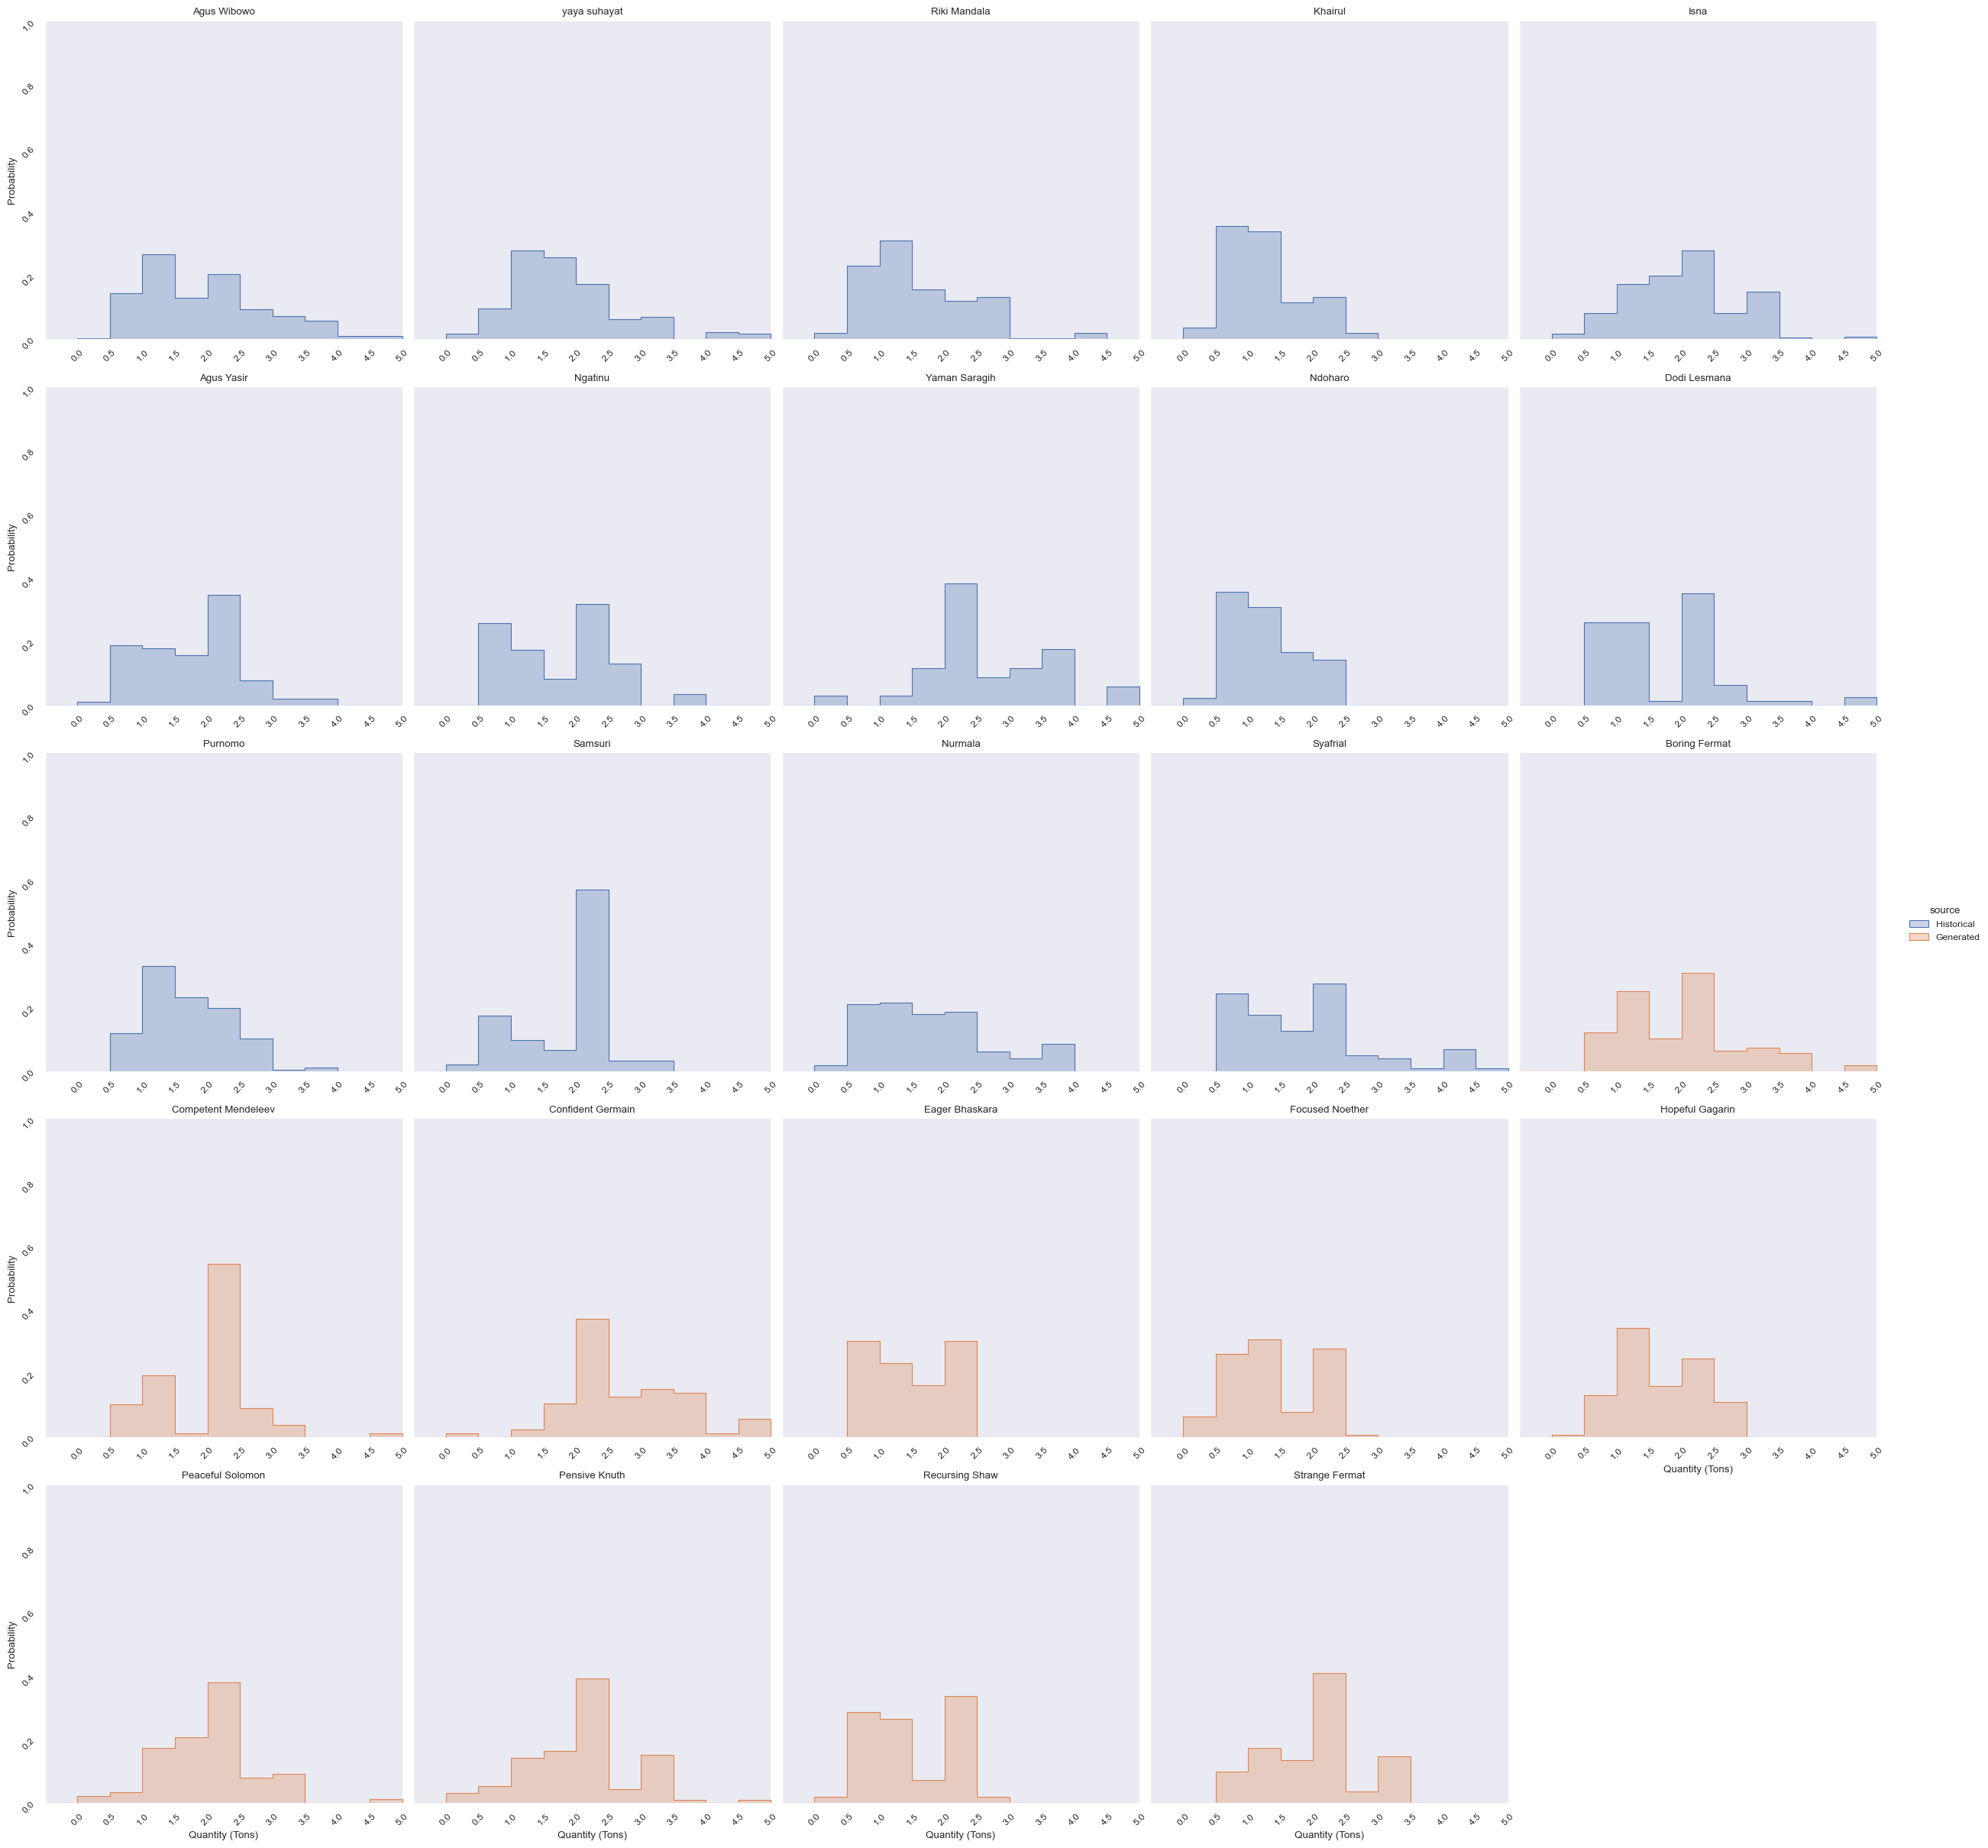

In [27]:
# 1. Prepare the two datasets
df_hist = farmers_df[['int_id', 'quantity']].copy()
df_hist['source'] = 'Historical'

df_gen = df[['int_id', 'quantity']].copy()
df_gen['source'] = 'Generated'

# 2. Combine them
df_combined = pd.concat([df_hist, df_gen], ignore_index=True)

# 3. Define Bins (shared for both)
max_q = df_combined['quantity'].max()
bins = np.arange(-0.5, max_q + 1.5, 0.5)

# 4. Plot using displot
g = sns.displot(
    data=df_combined,
    x='quantity',
    hue='source',
    col='int_id',
    col_wrap=5,
    bins=bins,
    stat='probability',
    common_norm=False,
    element='step',       # Highly recommended for overlays
    alpha=0.3,
    facet_kws={
        'sharex': True,
        'sharey': True
    }
)

# 5. Axis Formatting
xticks = np.arange(0, max_q + 1, 0.5)
for ax in g.axes.flatten():
    ax.set_xticks(xticks)
    ax.set_xlim(-0.5, max_q + 0.5)
    ax.tick_params(labelbottom=True, rotation=45) # Rotate for readability

g.set(ylim=(0, 1))
g.set_titles("{col_name}")
g.set_axis_labels("Quantity (Tons)", "Probability")

g.figure.subplots_adjust(hspace=0.15)

# g.figure.suptitle('Distribution of quantity (by intermediary)', fontsize=14)
g.figure.subplots_adjust(top=0.955)
plt.show()

### Verify farmer-intermediary distances match

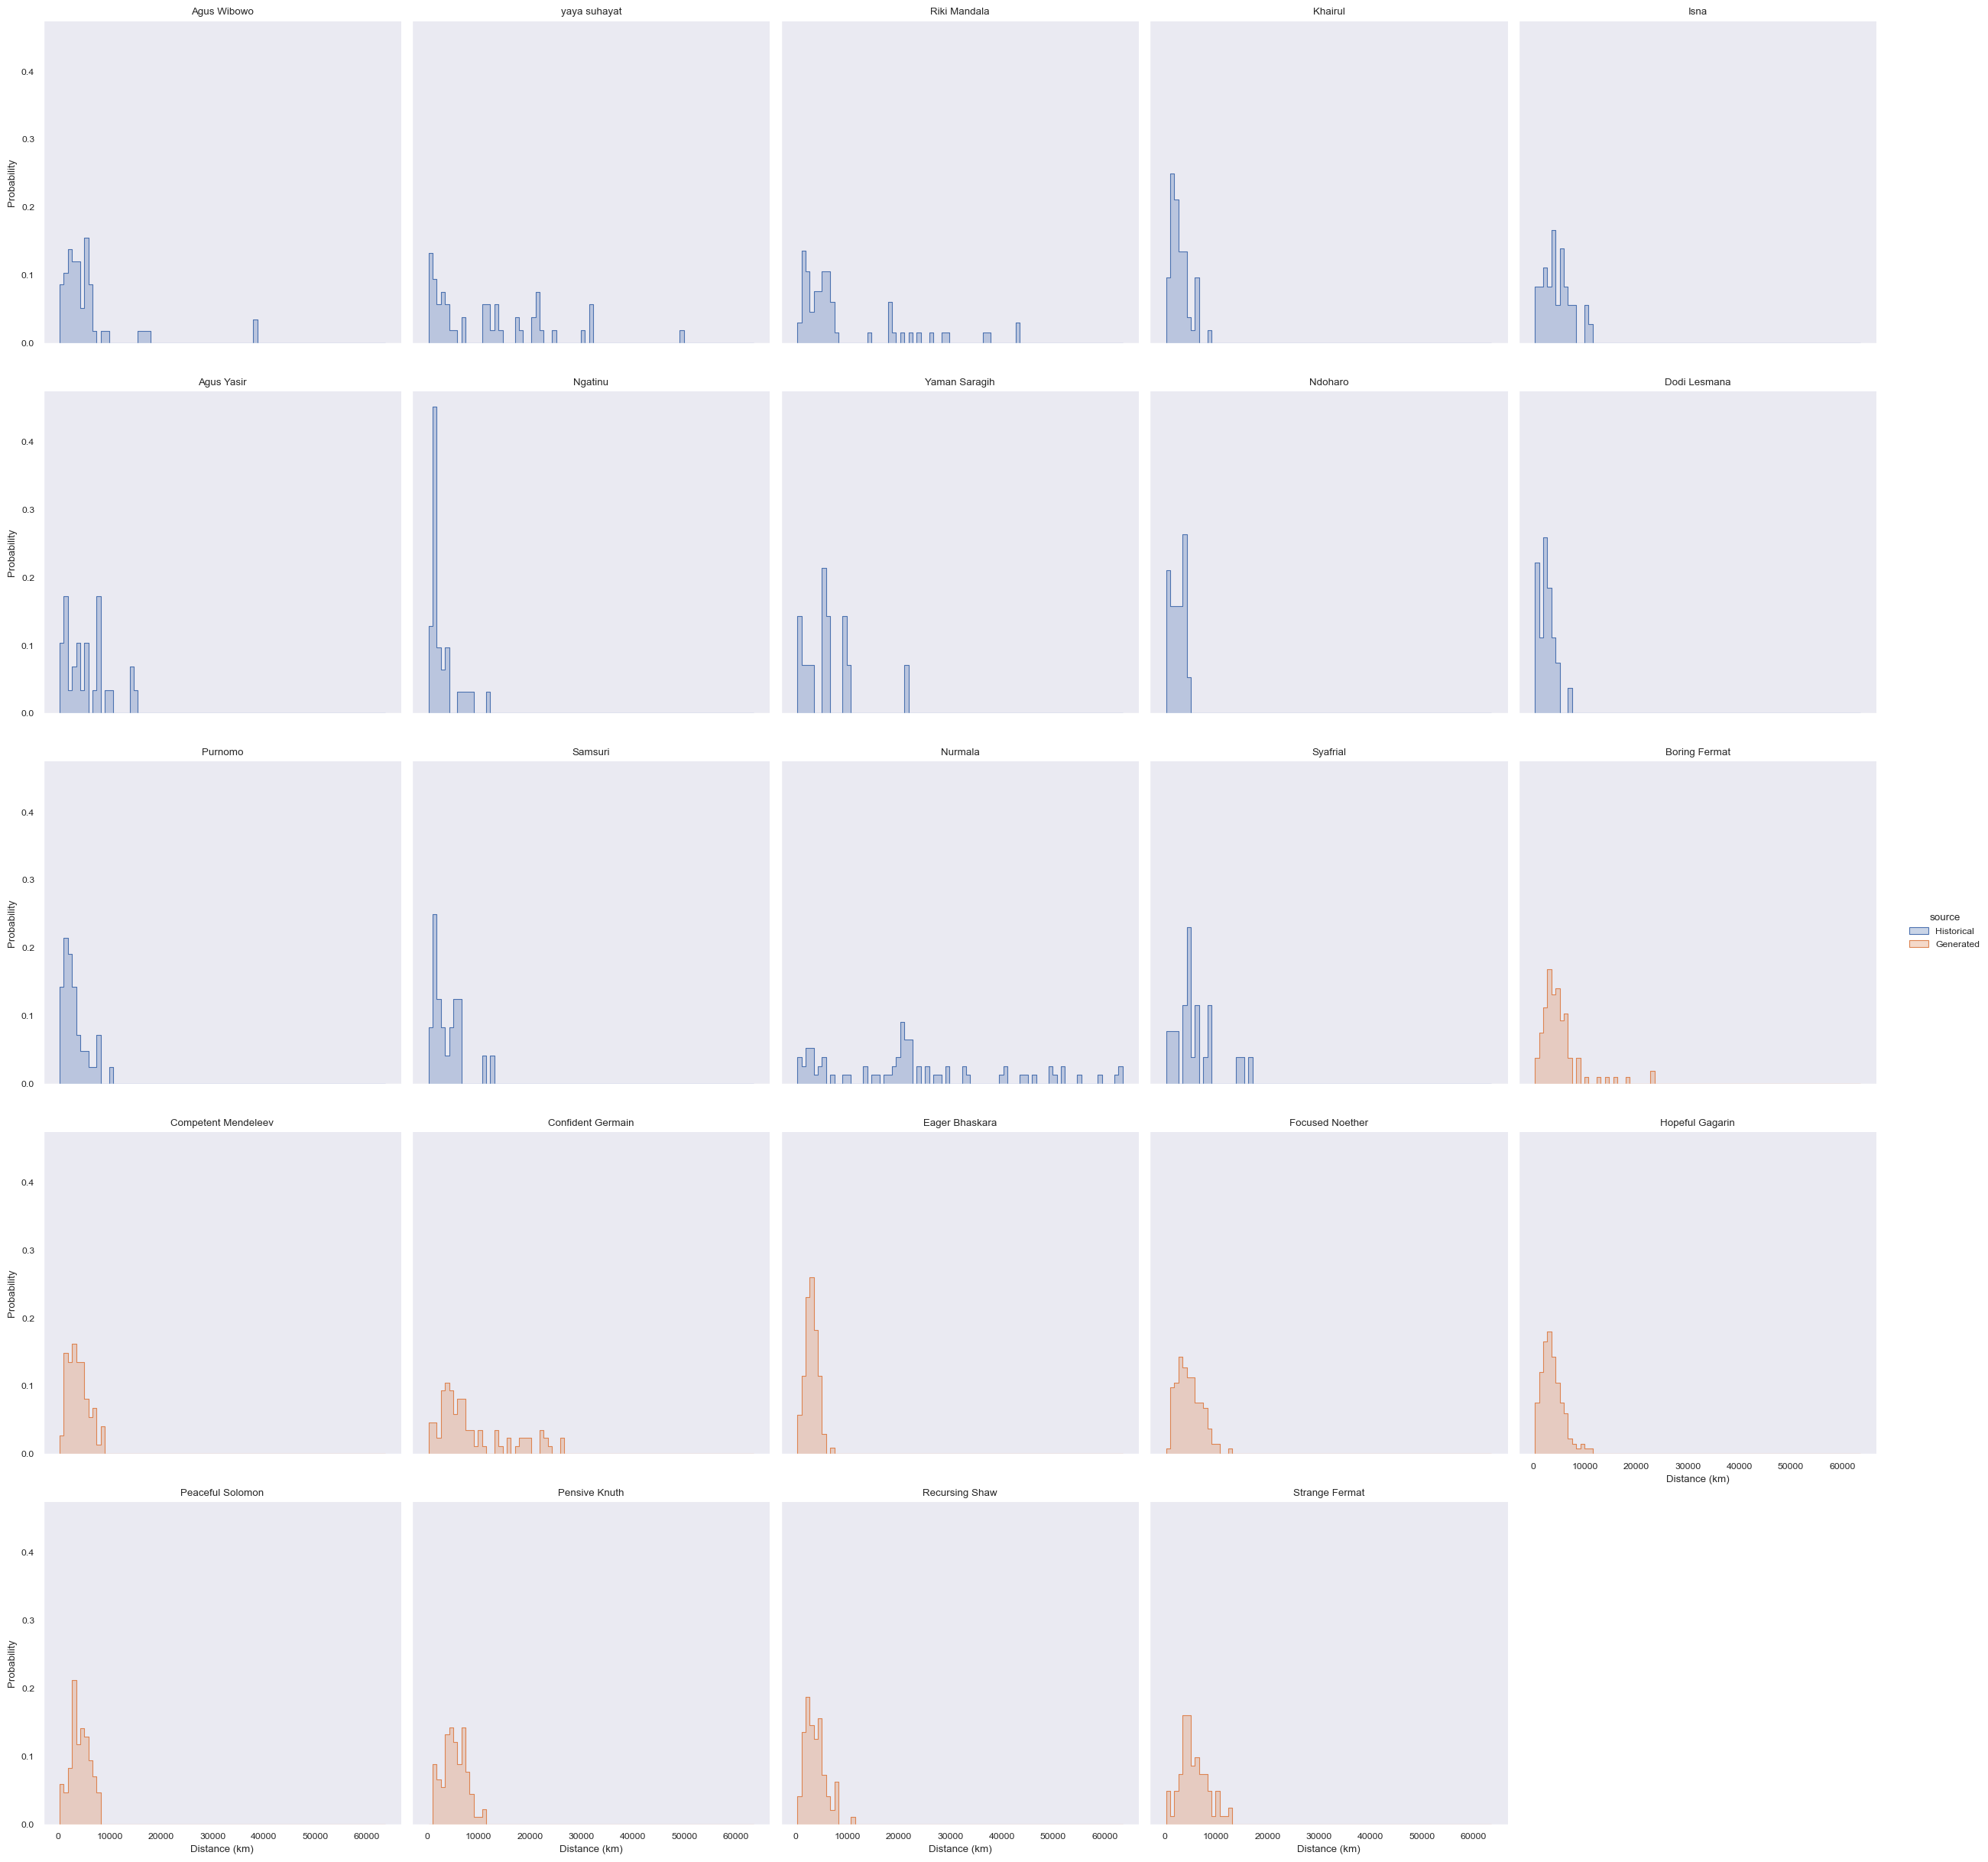

In [29]:
dist_hist = farmers_df.drop_duplicates(['int_id', 'farmer_x', 'farmer_y'])
dist_hist['source'] = 'Historical'

dist_gen = df.drop_duplicates(['int_id', 'farmer_x', 'farmer_y'])
dist_gen['source'] = 'Generated'

df_combined = pd.concat([dist_hist, dist_gen], ignore_index=True)


g = sns.displot(
    data=df_combined,
    x='distance',
    hue='source',
    col='int_id',
    col_wrap=5,
    stat='probability',
    common_norm=False,
    element='step',
    alpha=0.3,
    facet_kws={'sharex': True, 'sharey': True}
)

g.set_axis_labels("Distance (km)", "Probability")
g.set_titles("{col_name}")

g.figure.subplots_adjust(hspace=0.15)

# g.figure.suptitle('Distribution of farmer-intermediary distances', fontsize=14)
g.figure.subplots_adjust(top=0.965)

plt.show()


In [30]:
import networkx as nx
import osmnx as ox
import pandas as pd
from functools import lru_cache

# ---------------------------------------------------------
# 1. PRE-PROCESSING: Map nodes once to avoid redundant spatial queries
# ---------------------------------------------------------
def prepare_node_mapping(df_list, graph):
    """Maps unique farmer coordinates to graph nodes across all dataframes."""
    full_df = pd.concat([d[['farmer_x', 'farmer_y']] for d in df_list]).drop_duplicates()
    
    print(f"Mapping {len(full_df)} unique farmer locations to graph nodes...")
    full_df['node_id'] = ox.nearest_nodes(graph, full_df.farmer_x, full_df.farmer_y)
    
    return full_df

# ---------------------------------------------------------
# 2. CACHED DIJKSTRA: Memoize shortest path calculations
# ---------------------------------------------------------
@lru_cache(maxsize=10000)
def get_cached_distances(u, graph_id):
    """
    Computes and caches all-pairs distances from node u.
    graph_id is a dummy to ensure cache safety.
    """
    # Returns a dict of {target: distance}
    return nx.single_source_dijkstra_path_length(G_proj, u, weight='length')

# ---------------------------------------------------------
# 3. FAST TSP SOLVER
# ---------------------------------------------------------
def solve_road_tsp_fast(group, graph):
    """
    Solves TSP using cached distances and a greedy approximation.
    """
    # Filter nodes that actually exist in the graph
    nodes = [n for n in group['node_id'].unique() if n in graph]
    
    if len(nodes) < 2:
        return 0.0
    
    # Build distance matrix from cache
    dist_matrix = {}
    for u in nodes:
        # Fetching from cache is O(1) after first encounter
        all_dists = get_cached_distances(u, id(graph))
        dist_matrix[u] = {v: all_dists[v] for v in nodes if v in all_dists}

    valid_nodes = list(dist_matrix.keys())
    if len(valid_nodes) < 2:
        return 0.0

    # Create the complete graph for the TSP solver
    TSP_G = nx.Graph()
    for i, u in enumerate(valid_nodes):
        for v in valid_nodes[i+1:]:
            if v in dist_matrix[u]:
                TSP_G.add_edge(u, v, weight=dist_matrix[u][v])

    try:
        # greedy_tsp is much faster than Christofides (default) for large batches
        tsp_path = nx.approximation.traveling_salesman_problem(
            TSP_G, 
            cycle=False, 
            # method=nx.approximation.greedy_tsp
        )
        
        total_road_dist = sum(
            dist_matrix[tsp_path[i]][tsp_path[i+1]] 
            for i in range(len(tsp_path) - 1)
        )
        return total_road_dist
    except Exception:
        return -1.0

# ---------------------------------------------------------
# 4. WRAPPER FUNCTION
# ---------------------------------------------------------
def get_daily_tsp_dist(input_df, graph):
    """Groups data and calculates daily road distances."""
    # Group and apply the fast solver
    daily_dist = input_df.groupby(['int_id', 'date']).apply(
        lambda x: solve_road_tsp_fast(x, graph), 
        include_groups=False
    )
    
    # Filter and convert to KM
    res = daily_dist[daily_dist > 0].reset_index(name='km')
    res['km'] = res['km'] / 1000.0
    return res

# ---------------------------------------------------------
# 5. EXECUTION PIPELINE
# ---------------------------------------------------------

# First, map nodes once for both dataframes
node_map = prepare_node_mapping([farmers_df, df], G_proj)

# Join the mapping back to original data
hist_data = farmers_df.merge(node_map, on=['farmer_x', 'farmer_y'], how='left')
gen_data = df.merge(node_map, on=['farmer_x', 'farmer_y'], how='left')

print("Starting TSP calculations for Historical data...")
dist_hist = get_daily_tsp_dist(hist_data, G_proj)
dist_hist['source'] = 'Historical'

print("Starting TSP calculations for Generated data...")
dist_gen = get_daily_tsp_dist(gen_data, G_proj)
dist_gen['source'] = 'Generated'

# Combine results
df_combined = pd.concat([dist_hist, dist_gen], ignore_index=True)

Mapping 1495 unique farmer locations to graph nodes...
Starting TSP calculations for Historical data...
Starting TSP calculations for Generated data...


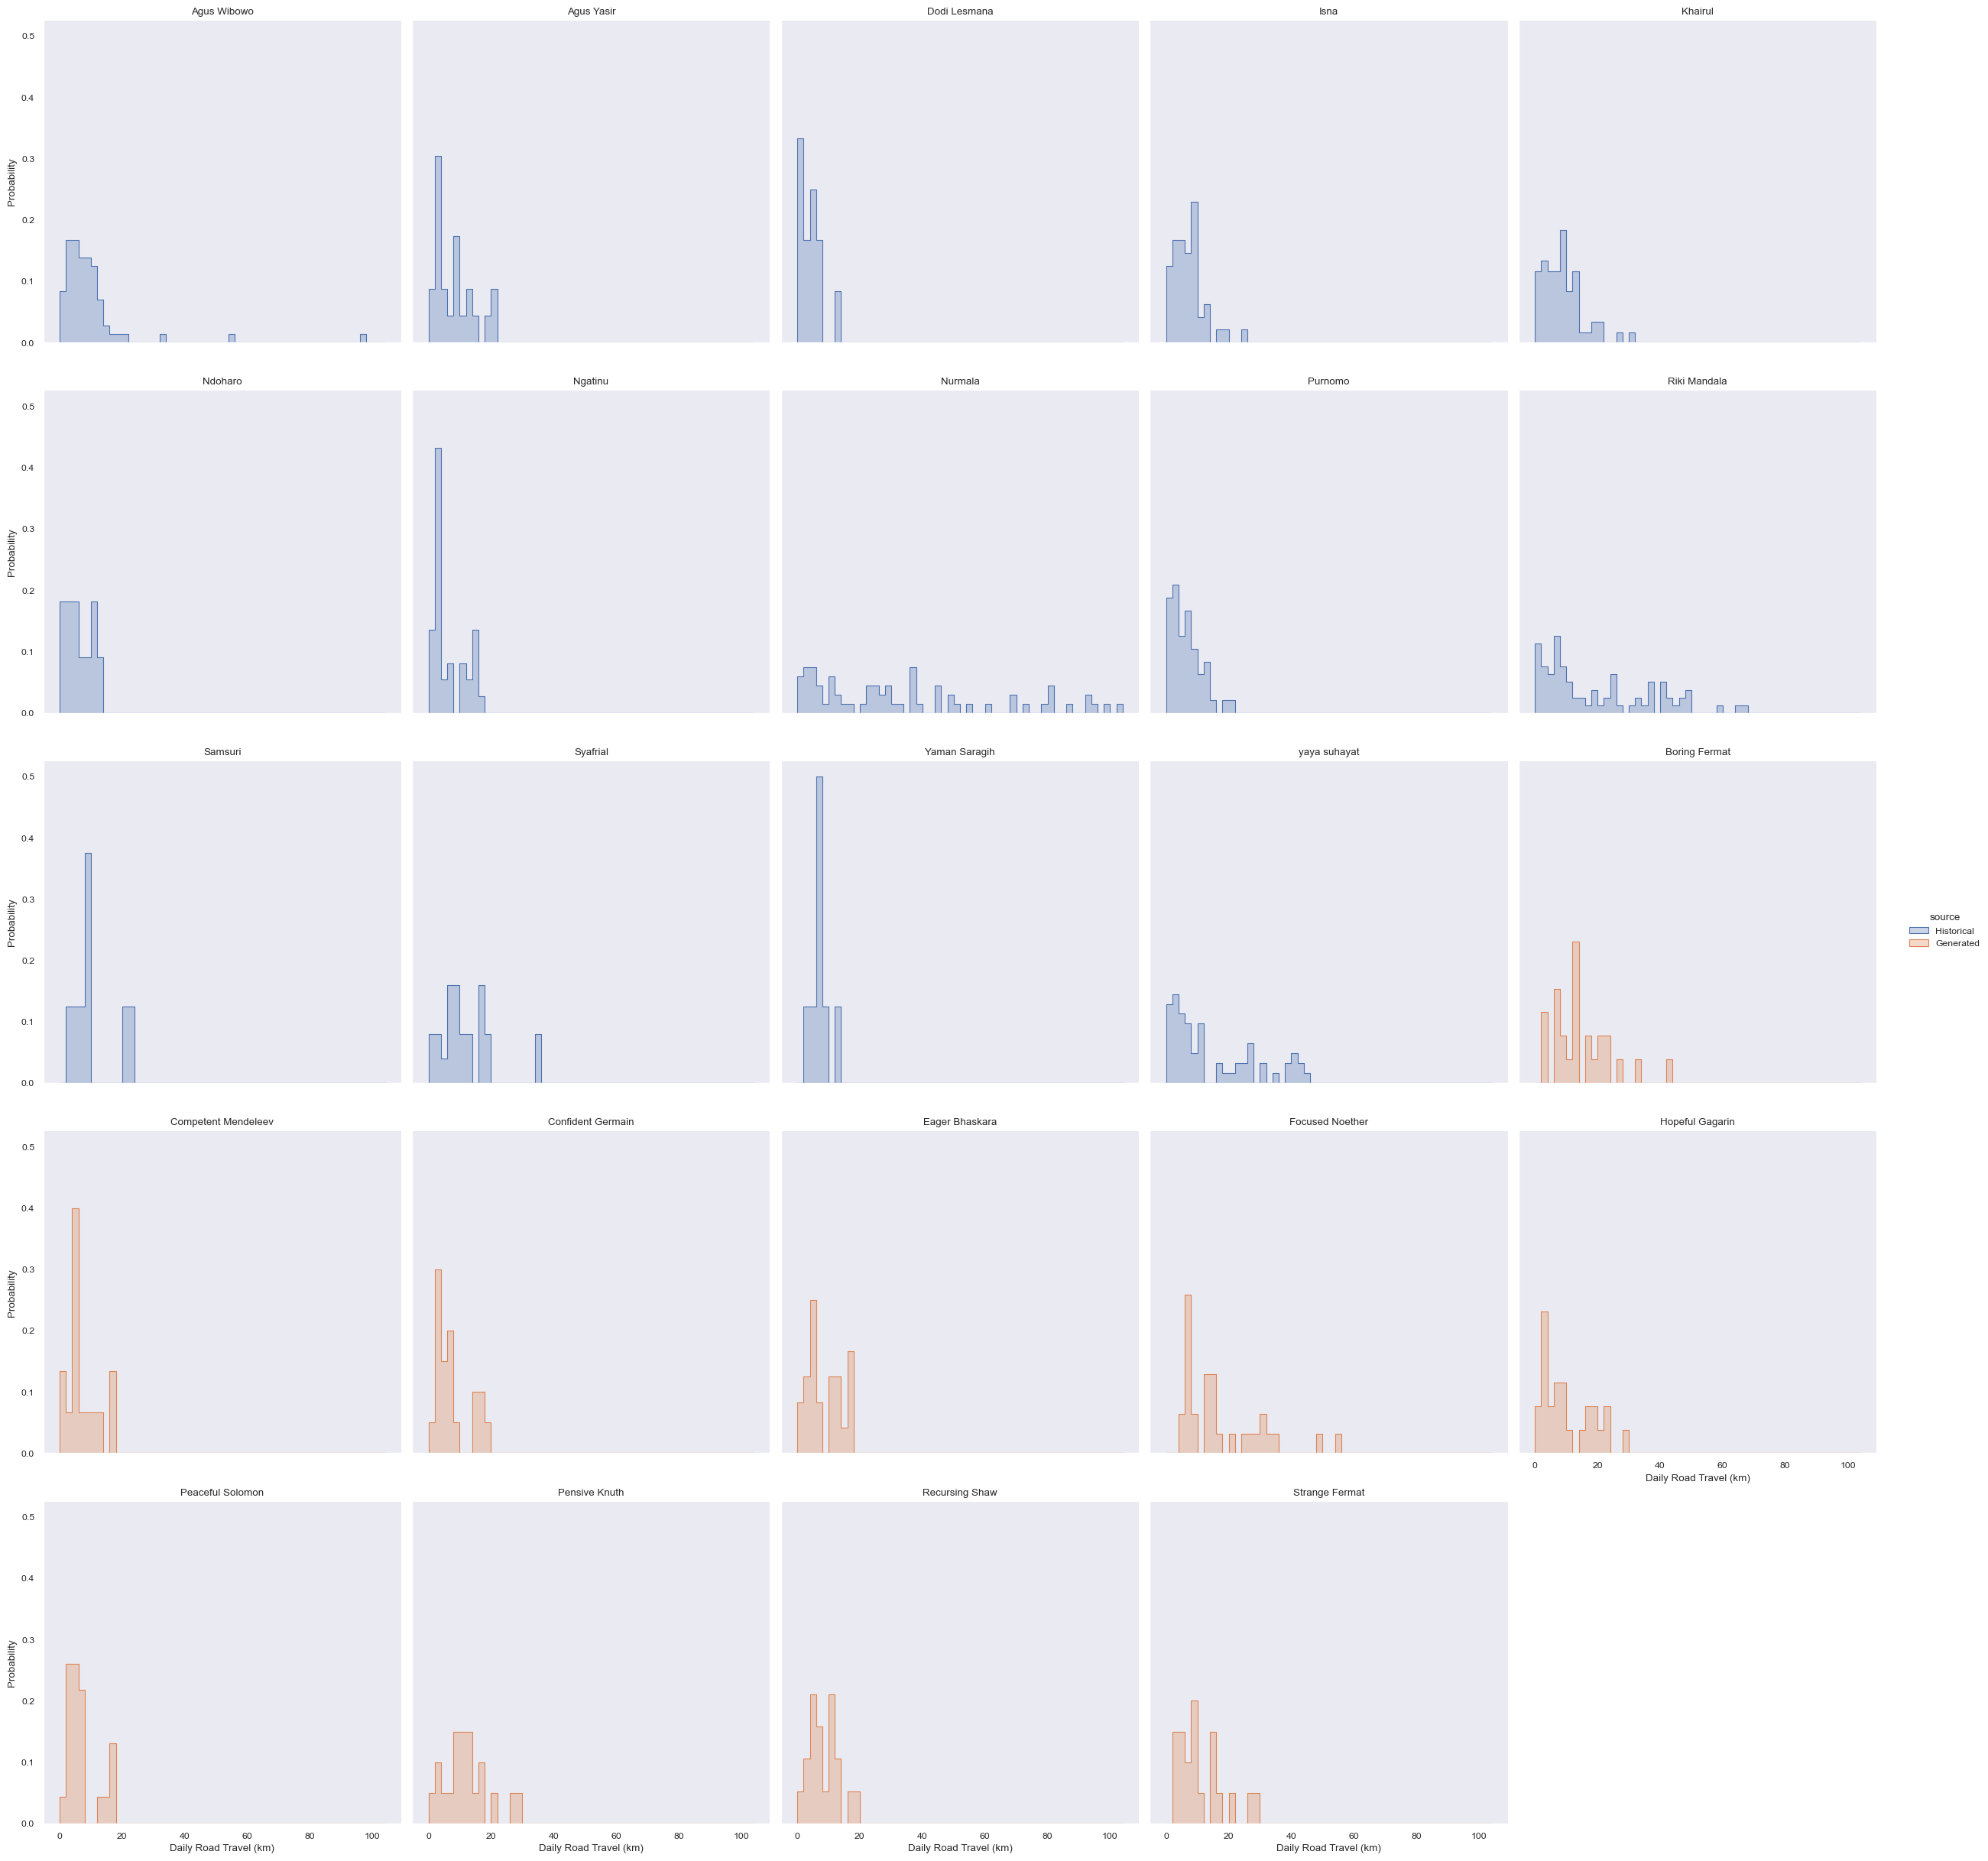

In [31]:
max_km = df_combined['km'].max()
bins = np.arange(0, max_km + 2, 2) # 2km bins for visibility

g = sns.displot(
    data=df_combined,
    x='km',
    hue='source',
    col='int_id',
    col_wrap=5,
    bins=bins,
    stat='probability',
    common_norm=False,
    element='step',
    alpha=0.3,
    facet_kws={'sharex': True, 'sharey': True}
)

# 5. Formatting
g.set_axis_labels("Daily Road Travel (km)", "Probability")
g.set_titles("{col_name}")

g.figure.subplots_adjust(hspace=0.15)

# g.figure.suptitle('Distribution of daily TSP tour length (by intermediary)', fontsize=14)
g.figure.subplots_adjust(top=0.965)

plt.show()